In [1]:
import sys

from sklearn.preprocessing import Normalizer

sys.path.append("../..")

import pandas as pd
from sklearn.decomposition import FastICA


data = pd.read_csv("../../data/sun_et_al_data/mpa4_species_profile_after_abundance_prevalence_filtering.csv", index_col=0, header=0)
metadata = pd.read_csv("../../data/sun_et_al_data/sample_group_species_preprocessed.csv", index_col=0, header=0)

print((data == 0).sum().sum() / data.shape[0] / data.shape[1])


# data = pd.DataFrame(
#             Normalizer().fit_transform(data),
#             index=data.index,
#             columns=data.columns,
#         )

# data = data * 1e4

# feature_reducer = FastICA(n_components=1500)
# reduced_data = feature_reducer.fit_transform(data)
# reduced_data = pd.DataFrame(reduced_data, index=data.index)
# display(reduced_data.head())

0.9652543924586382


# PCA Feature Selection

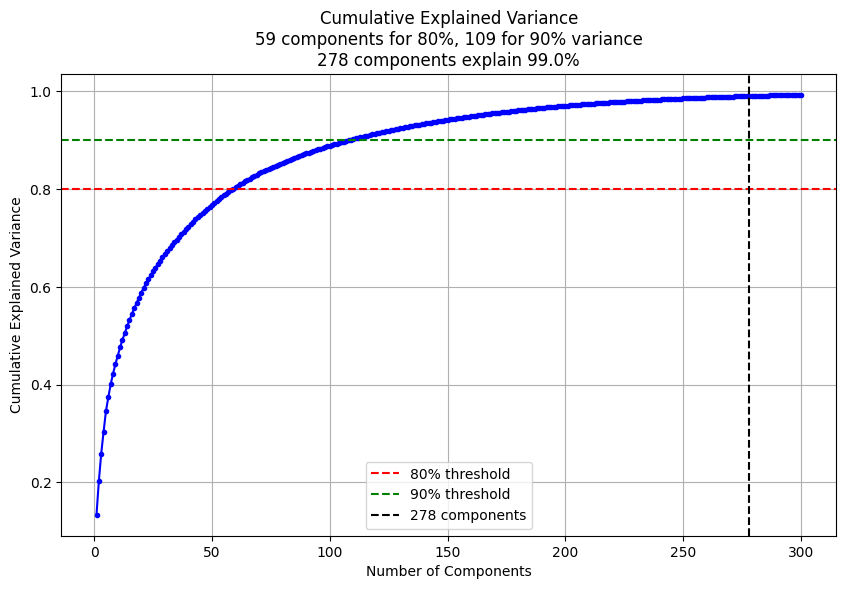

Optimal number of components for 80% variance:
59
Optimal number of components for 90% variance:
109
Variance explained by 278 components:
99.0%
Optimal number of components for 99% variance:
278


In [2]:
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def check_optimal_components(X, max_components=300):
    """Plot cumulative explained variance to determine optimal number of components"""
    # Run PCA with maximum possible components
    max_comp = min(max_components, min(X.shape))
    pca = PCA(n_components=max_comp)
    pca.fit(X)
    
    # Calculate cumulative explained variance
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, len(cum_var) + 1), cum_var, 'b-', marker='o', markersize=3)
    ax.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    ax.axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
    ax.axvline(x=278, color='k', linestyle='--', label='278 components')
    
    # Calculate components needed for thresholds
    comp_80 = np.where(cum_var >= 0.8)[0][0] + 1
    comp_90 = np.where(cum_var >= 0.9)[0][0] + 1
    var_200 = cum_var[277] if len(cum_var) > 277 else cum_var[-1]
    comp_99 = np.where(cum_var >= 0.99)[0][0] + 1 if np.any(cum_var >= 0.99) else None
    
    ax.set_title(f'Cumulative Explained Variance\n{comp_80} components for 80%, {comp_90} for 90% variance\n278 components explain {var_200:.1%}')
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.grid(True)
    ax.legend()

    plt.show()
    print(f"Optimal number of components for 80% variance:\n{comp_80}")
    print(f"Optimal number of components for 90% variance:\n{comp_90}")
    print(f"Variance explained by 278 components:\n{var_200:.1%}")
    print(f"Optimal number of components for 99% variance:\n{comp_99 if comp_99 is not None else 'Not reached'}")

    fig.savefig("optimal_components_plot.png", dpi=300, bbox_inches='tight')
    
    # return fig, comp_80, comp_90, var_200

X = pd.read_csv("../../data/sun_et_al_data/mpa4_species_profile_preprocessed.csv", index_col=0, header=0)
check_optimal_components(X, max_components=300)




In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import pandas as pd
sys.path.append("../..")
import src.data.helper_functions as hf

X = pd.read_csv("../../data/sun_et_al_data/mpa4_species_profile_preprocessed.csv", index_col=0, header=0)
y = pd.read_csv("../../data/sun_et_al_data/sample_group_species_preprocessed.csv", index_col=0, header=0)

variance_thresholds = list(range(80, 101, 2)) + [99]
n_components = [278, 59, 500, 1000]

results = {}
results["sqrt"] = {}
results["linear"] = {}
results["log"] = {}
results["none"] = {}

for n_comp in n_components:
    for var_thr in variance_thresholds:
        print(f"Processing n_components={n_comp}, variance_threshold={var_thr}")
        selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(
            X, variance_threshold=var_thr / 100, n_components=n_comp, weighting="sqrt"
        )
        if n_comp not in results["sqrt"]:
            results["sqrt"][n_comp] = {}
        results["sqrt"][n_comp][var_thr] = len(selected_features)

for weighting in ["linear", "log", "none"]:
    for var_thr in variance_thresholds:
        print(f"Processing weighting={weighting}, n_components={n_comp}, variance_threshold={var_thr}")
        selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(
            X, variance_threshold=var_thr / 100, n_components=278, weighting=weighting
        )
        if 278 not in results[weighting]:
            results[weighting][278] = {}
        results[weighting][278][var_thr] = len(selected_features)

print(results)

# print(X.shape)
# print(278)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=278)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=278)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=278)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=278)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=278)
# print(59)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=59)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=59)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=59)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=59)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=59)
# print(600)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=600)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=600)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=600)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=600)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=600)
# print(1000)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=1000)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=1000)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=1000)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=1000)
# selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=1000)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Processing n_components=278, variance_threshold=80
Processing n_components=278, variance_threshold=82
Processing n_components=278, variance_threshold=84
Processing n_components=278, variance_threshold=86
Processing n_components=278, variance_threshold=88
Processing n_components=278, variance_threshold=90
Processing n_components=278, variance_threshold=92
Processing n_components=278, variance_threshold=94
Processing n_components=278, variance_threshold=96
Processing n_components=278, variance_threshold=98
Processing n_components=278, variance_threshold=100
Processing n_components=278, variance_threshold=99
Processing n_components=59, variance_threshold=80
Processing n_components=59, variance_threshold=82
Processing n_components=59, variance_threshold=84
Processing n_components=59, variance_threshold=86
Processing n_components=59, variance_threshold=88
Processing n_components=59, variance_threshold=90

: 

In [21]:
print(59)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=500)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=500)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=500)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=500)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=500)

59
Selected 1360 features to explain 95.0% of weighted variance
Selected 359 features to explain 85.0% of weighted variance
Selected 304 features to explain 80.0% of weighted variance
Selected 451 features to explain 90.0% of weighted variance
Selected 2318 features to explain 99.0% of weighted variance


In [22]:
print(499)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=499)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=499)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=499)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=499)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=499)

print(495)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=495)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=495)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=495)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=495)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=495)

print(450)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=450)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=450)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=450)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=450)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=450)

499
Selected 1360 features to explain 95.0% of weighted variance
Selected 359 features to explain 85.0% of weighted variance
Selected 304 features to explain 80.0% of weighted variance
Selected 451 features to explain 90.0% of weighted variance
Selected 2318 features to explain 99.0% of weighted variance
495
Selected 1359 features to explain 95.0% of weighted variance
Selected 359 features to explain 85.0% of weighted variance
Selected 304 features to explain 80.0% of weighted variance
Selected 451 features to explain 90.0% of weighted variance
Selected 2318 features to explain 99.0% of weighted variance
450
Selected 1359 features to explain 95.0% of weighted variance
Selected 354 features to explain 85.0% of weighted variance
Selected 300 features to explain 80.0% of weighted variance
Selected 443 features to explain 90.0% of weighted variance
Selected 2318 features to explain 99.0% of weighted variance


In [20]:
print("linear")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=278, weighting="linear")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=278, weighting="linear")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=278, weighting="linear")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=278, weighting="linear")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=278, weighting="linear")
print("log")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=278, weighting="log")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=278, weighting="log")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=278, weighting="log")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=278, weighting="log")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=278, weighting="log")
print("none")
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.95, n_components=278, weighting=None)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.85, n_components=278, weighting=None)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.80, n_components=278, weighting=None)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.9, n_components=278, weighting=None)
selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X, variance_threshold=0.99, n_components=278, weighting=None)

linear
Selected 1686 features to explain 95.0% of weighted variance
Selected 323 features to explain 85.0% of weighted variance
Selected 238 features to explain 80.0% of weighted variance
Selected 816 features to explain 90.0% of weighted variance
Selected 2383 features to explain 99.0% of weighted variance
log
Selected 1653 features to explain 95.0% of weighted variance
Selected 315 features to explain 85.0% of weighted variance
Selected 236 features to explain 80.0% of weighted variance
Selected 749 features to explain 90.0% of weighted variance
Selected 2377 features to explain 99.0% of weighted variance
none
Selected 1133 features to explain 95.0% of weighted variance
Selected 317 features to explain 85.0% of weighted variance
Selected 279 features to explain 80.0% of weighted variance
Selected 391 features to explain 90.0% of weighted variance
Selected 2271 features to explain 99.0% of weighted variance


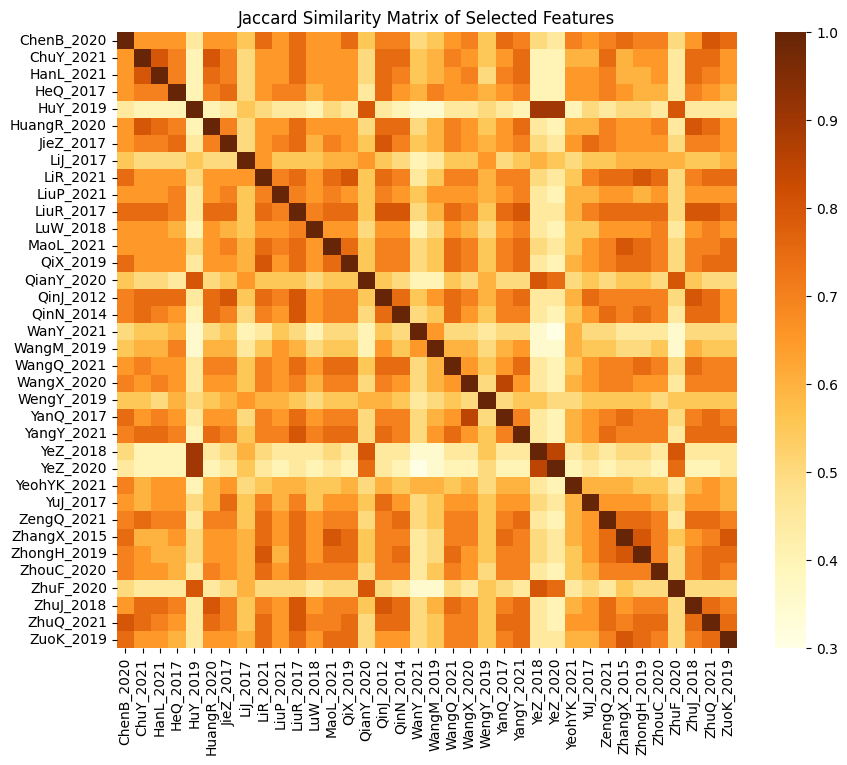

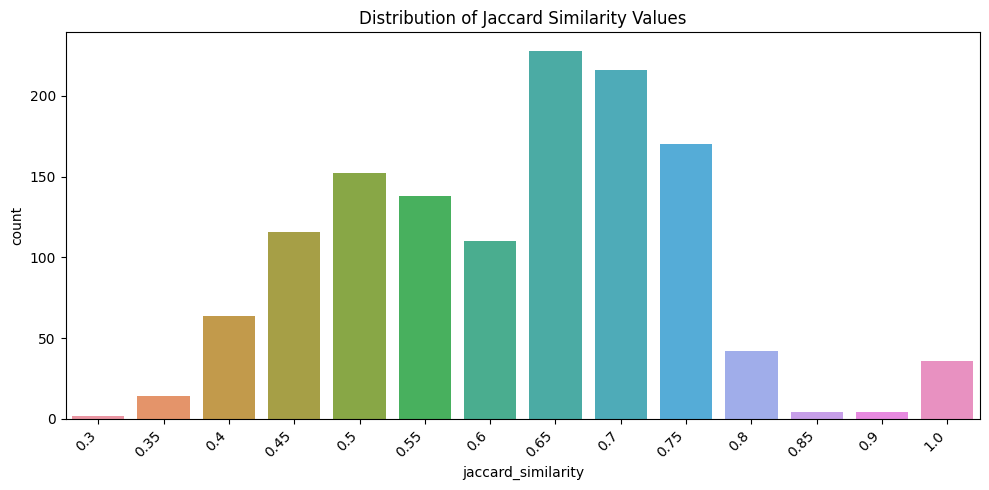

In [ ]:
# feature selection per study
# groups = y.groupby("Project_1")
# selected_features_per_study = {}

# for name, idx in groups.groups.items():
#     selected_features, selected_features_df, pc_contributions, pca = hf.select_features_by_explained_variance(X.loc[idx], variance_threshold=0.90, n_components=200)
#     selected_features_per_study[name] = set(selected_features)

# jaccard similarity matrix between studies selected features
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def jaccard_similarity_matrix(selected_features_per_study):
    studies = list(selected_features_per_study.keys())
    jaccard_matrix = np.zeros((len(studies), len(studies)))

    for i, s1 in enumerate(studies):
        for j, s2 in enumerate(studies):
            set1 = selected_features_per_study[s1]
            set2 = selected_features_per_study[s2]
            # Calculate the intersection and union sizes:
            intersection_size = len(set1.intersection(set2))
            union_size = len(set1.union(set2))
            # Avoid division by zero
            jaccard_matrix[i, j] = (
                intersection_size / union_size if union_size > 0 else np.nan
            )

    return pd.DataFrame(jaccard_matrix, index=studies, columns=studies)

jaccard_matrix = jaccard_similarity_matrix(selected_features_per_study)

# Plot a heatmap using seaborn
def round_nearest(x, a):
    return round(x / a) * a

jaccard_df_rounded = round_nearest(jaccard_matrix, 0.05)
plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_df_rounded, annot=False, fmt=".1f", cmap=sns.color_palette("YlOrBr", as_cmap=True), cbar=True)
plt.title("Jaccard Similarity Matrix of Selected Features")
plt.show()

# Convert the stacked dataframe to a proper value counts dataframe
jaccard_df_rounded_counting = jaccard_df_rounded.stack().reset_index()
jaccard_df_rounded_counting[0] = jaccard_df_rounded_counting[0].apply(lambda x: round(x, 2))

# Get value counts and convert to a DataFrame suitable for plotting
similarity_counts = jaccard_df_rounded_counting[0].value_counts().reset_index()
similarity_counts.columns = ["jaccard_similarity", "count"]

# Plot using the properly formatted DataFrame
plt.figure(figsize=(10, 5))
sns.barplot(x="jaccard_similarity", y="count", data=similarity_counts)
plt.title("Distribution of Jaccard Similarity Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()